In [31]:
import pandas as pd

In [32]:
data= pd.read_csv('/Users/yugo_suzuki/mydevelopment/development/dsプログラミング/shop-item/Sales Dataset.csv')
data.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


In [34]:
data.describe()

,Amount,Profit,Quantity
count,1194.000000,1194.000000,1194.000000
mean,5178.089615,1348.992462,10.674204
std,2804.921955,1117.992573,5.777102
min,508.000000,50.000000,1.000000
25%,2799.000000,410.000000,6.000000
50%,5152.000000,1014.000000,11.000000
75%,7626.000000,2035.000000,16.000000
max,9992.000000,4930.000000,20.000000


In [35]:
data.isnull().sum()

Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Order Date      0
CustomerName    0
State           0
City            0
Year-Month      0
dtype: int64

In [36]:
# 各カテゴリ変数のユニークな値を表示
print("カテゴリーの種類:", data["Category"].unique())
print("サブカテゴリーの種類:", data["Sub-Category"].unique())
print("支払いの種類:", data["PaymentMode"].unique())

カテゴリーの種類: ['Electronics' 'Office Supplies' 'Furniture']
サブカテゴリーの種類: ['Electronic Games' 'Printers' 'Pens' 'Laptops' 'Tables' 'Chairs'
 'Markers' 'Sofas' 'Paper' 'Binders' 'Phones' 'Bookcases']
支払いの種類: ['UPI' 'Debit Card' 'EMI' 'Credit Card' 'COD']


年月ごとのデータの形を変換させる。適切な形にする
地域ごとのAmountとprofitとQuantityを棒グラフとして出力させる

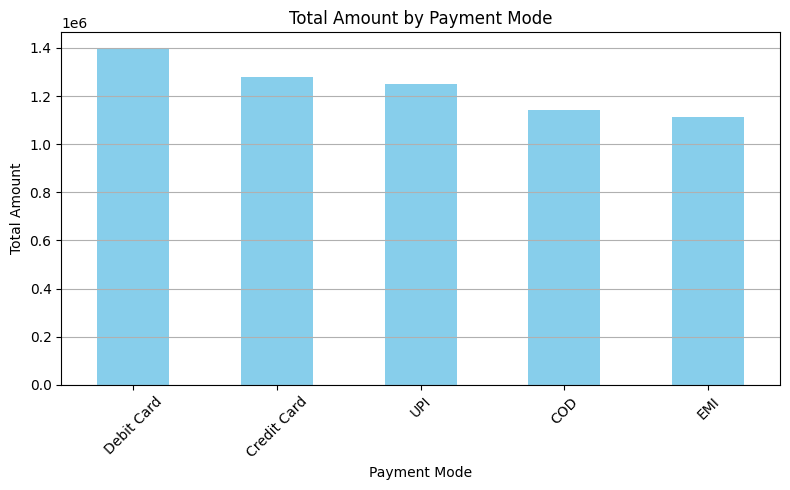

In [37]:

import matplotlib.pyplot as plt
# 支払い方法ごとの合計金額を集計
payment_summary = data.groupby('PaymentMode')['Amount'].sum().sort_values(ascending=False)

# グラフ作成
plt.figure(figsize=(8, 5))
payment_summary.plot(kind='bar', color='skyblue')
plt.title('Total Amount by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


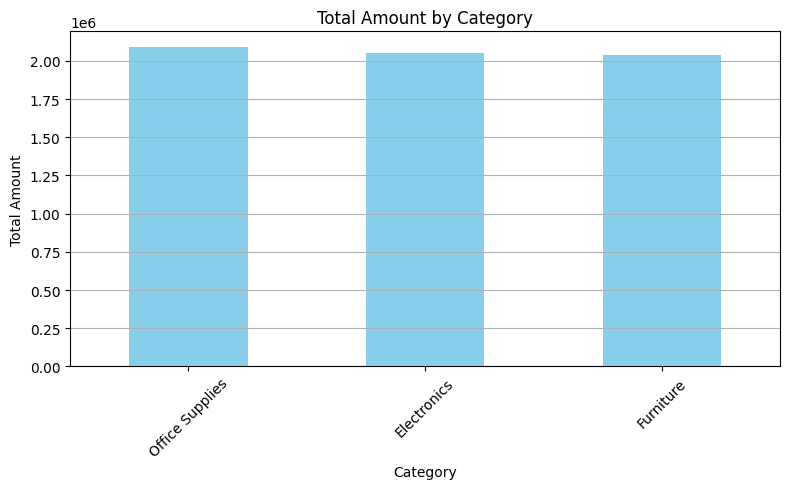

In [38]:
Category_summarau = data.groupby('Category')['Amount'].sum().sort_values(ascending=False)
# グラフ作成
plt.figure(figsize=(8, 5)) ##グラフのサイズを指定
Category_summarau.plot(kind='bar', color='skyblue')
plt.title('Total Amount by Category') ##タイトル
plt.xlabel('Category') ##x軸のラベル
plt.ylabel('Total Amount') ##y軸のラベル
plt.xticks(rotation=45) ##x軸のラベルを45度回転 
plt.tight_layout() ##レイアウトを調整
plt.grid(axis='y') ##y軸にグリッドを表示
plt.show() ##グラフを表示
# サブカテゴリーごとの合計金額を集計

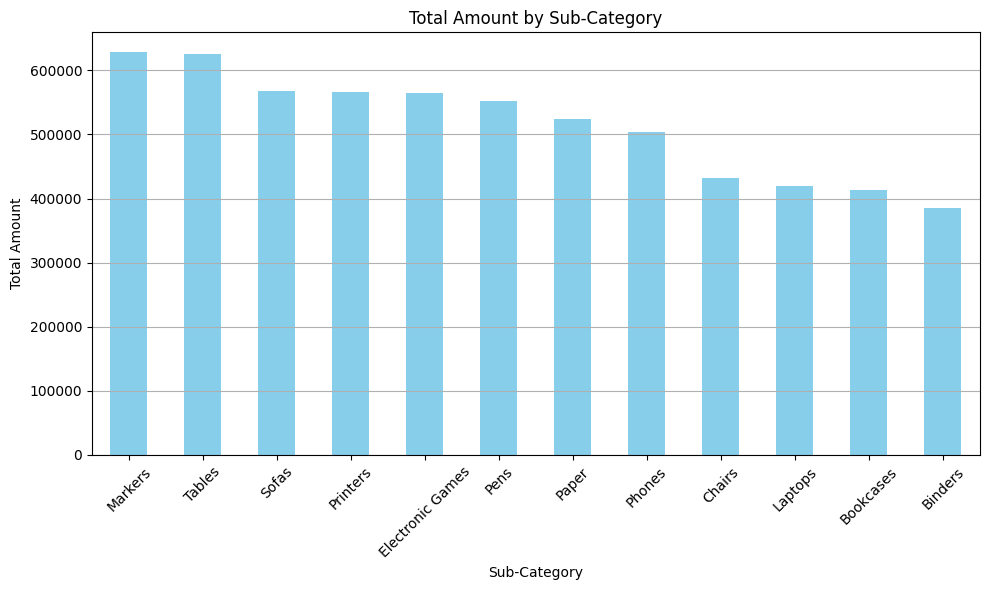

In [39]:
sub_category_summary = data.groupby('Sub-Category')['Amount'].sum().sort_values(ascending=False)
# グラフ作成
plt.figure(figsize=(10, 6))
sub_category_summary.plot(kind='bar', color='skyblue')
plt.title('Total Amount by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


In [49]:
## 年代ごとのamountの合計を集計そしてグラフ化
## 年代ごとのsub_categoryのamoutを集計そしてグラフ化

In [ ]:
# 'Order Date' を datetime 型に変換
data['Year-Month'] = pd.to_datetime(data['Year-Month'])

# 年代を抽出（例: 20代, 30代, 40代など）
data['Year-Month'] = ((2025 - data['Year-Month'].dt.year) // 10) * 10

# 年代ごとの Amount 合計を集計
age_group_amount = data.groupby('Age Group')['Amount'].sum().reset_index()

# 年代ごとの Amount 合計をグラフ化
plt.figure(figsize=(10, 6))
sns.barplot(x='Age Group', y='Amount', data=age_group_amount)
plt.title('Total Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.show()